In [3]:
import pandas as pd
import requests
from io import StringIO

# Import & Inspect

In [5]:
df = pd.read_csv("data/healthexp.csv")
df.head()

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9


In [6]:
# how many rows and columns I have
df.shape

(274, 4)

In [7]:
df.columns

Index(['Year', 'Country', 'Spending_USD', 'Life_Expectancy'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             274 non-null    int64  
 1   Country          274 non-null    object 
 2   Spending_USD     274 non-null    float64
 3   Life_Expectancy  274 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 8.7+ KB


# Validation

In [9]:
# Check the number of missing values in every column
df.isna().sum()

Year               0
Country            0
Spending_USD       0
Life_Expectancy    0
dtype: int64

In [10]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

# Analyse

In [11]:
# descriptive statistic
df.describe()

,Year,Spending_USD,Life_Expectancy
count,274.000000,274.000000,274.000000
mean,1996.992701,2789.338905,77.909489
std,14.180933,2194.939785,3.276263
min,1970.000000,123.993000,70.600000
25%,1985.250000,1038.357000,75.525000
50%,1998.000000,2295.578000,78.100000
75%,2009.000000,4055.610000,80.575000
max,2020.000000,11859.179000,84.700000


In [12]:
df["Country"].value_counts()

Country
Japan            51
USA              51
Germany          50
Canada           44
Great Britain    43
France           35
Name: count, dtype: int64

In [13]:
# The average life expenctancy by country
df.groupby("Country")["Life_Expectancy"].mean()

Country
Canada           78.706818
France           79.565714
Germany          76.726000
Great Britain    77.620930
Japan            79.554902
USA              75.843137
Name: Life_Expectancy, dtype: float64

In [15]:
# Sort from largest to smallest
df.groupby("Country")["Life_Expectancy"].mean().sort_values(ascending=False)

Country
France           79.565714
Japan            79.554902
Canada           78.706818
Great Britain    77.620930
Germany          76.726000
USA              75.843137
Name: Life_Expectancy, dtype: float64

In [16]:
df.groupby("Country")["Spending_USD"].mean().sort_values(ascending=False)

Country
USA              4388.570529
France           3045.145057
Canada           2685.778341
Germany          2667.280200
Great Britain    2034.192465
Japan            1860.257902
Name: Spending_USD, dtype: float64

In [18]:
country_summary = df.groupby("Country")[["Spending_USD", "Life_Expectancy"]].mean()
country_summary

,Spending_USD,Life_Expectancy
Country,,
Canada,2685.778341,78.706818
France,3045.145057,79.565714
Germany,2667.280200,76.726000
Great Britain,2034.192465,77.620930
Japan,1860.257902,79.554902
USA,4388.570529,75.843137


In [19]:
# Correlation between health spending and life expectancy
df["Spending_USD"].corr(df["Life_Expectancy"])

np.float64(0.5794304588530951)

# Visualisation

In [20]:
import matplotlib.pyplot as plt

In [21]:
life_exp_by_country = df.groupby("Country")["Life_Expectancy"].mean().sort_values(ascending=False)

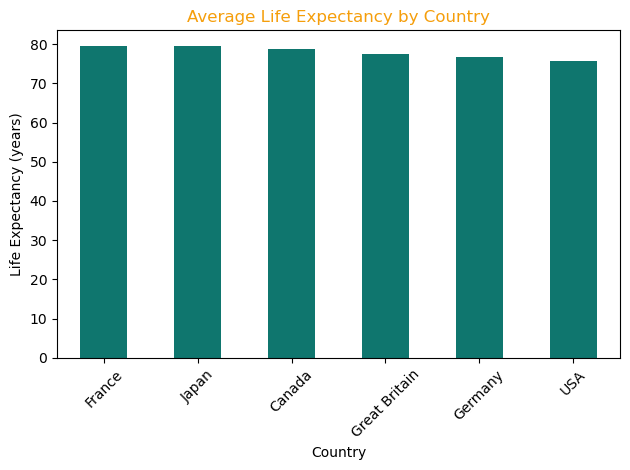

In [33]:
# Create a bar chart from the calculated averages and color
life_exp_by_country.plot(kind="bar", color="#0F766E")

# Add a title to the chart
plt.title("Average Life Expectancy by Country", color="#F59E0B")

# Label the x-axis
plt.xlabel("Country")

# Label the y-axis
plt.ylabel("Life Expectancy (years)")

# Rotate country names so they are easier to read
plt.xticks(rotation=45)

# Adjust the layout so labels do not overlap
plt.tight_layout()

# Display the chart
plt.show()

# Export

In [34]:
# Export the country summary to a CSV file
# index=True keeps the country names in the exported file
country_summary.to_csv("output/country_summary.csv", index=True)

In [35]:
# Read the exported CSV file back into pandas
exported_summary = pd.read_csv("output/country_summary.csv")

# Display the exported data
exported_summary

,Country,Spending_USD,Life_Expectancy
0,Canada,2685.778341,78.706818
1,France,3045.145057,79.565714
2,Germany,2667.280200,76.726000
3,Great Britain,2034.192465,77.620930
4,Japan,1860.257902,79.554902
5,USA,4388.570529,75.843137


## Conclusion

The dataset contains health spending and life expectancy data for six countries between 1970 and 2020.
The analysis shows that average health spending varies considerably between countries. The USA has the highest average health spending, while Japan has the lowest.
Japan and France have the highest average life expectancy in this dataset, while the USA has the lowest.
The correlation between health spending and life expectancy is approximately 0.58, indicating a moderate positive relationship. However, correlation does not mean that higher health spending causes higher life expectancy.
### Overall, the analysis demonstrates how Python and pandas can be used to import, inspect, validate, analyse, visualise, and export a real-world dataset.